# Reverse Compiler Spatial Visualization Test



This notebook runs an end-to-end **spatial** visualization test (not timeline):

1. Build a schedule with movement + gates

2. Reverse compile to CircuitIR

3. Validate extracted events

4. Render per-step spatial snapshots: atom positions, move arrows, and gate highlights (circled atoms)



Recommended kernel/environment: **MQ-SDK**

In [10]:
from pathlib import Path
import sys

print('Python executable:', sys.executable)
print('Current directory :', Path.cwd())

Python executable: /opt/anaconda3/envs/MQ-SDK/bin/python
Current directory : /Users/bryantduan/Desktop/Compiler/Reverse_Compiler


In [11]:
from reverse_compiler import encode_circuit, reverse_compile, extract_atom_events



import matplotlib.pyplot as plt

from matplotlib.patches import Circle, FancyArrowPatch



# Sanity check imports

print('Imports OK')

Imports OK


In [12]:
# Build a self-contained physical circuit with both 1Q and 2Q gates.
# encode_circuit will insert rearrangeJob movement around entangling gates.
ops = [
    ('h', (0,)),
    ('rz', (0,), (0.37,)),
    ('rx', (1,), (1.2,)),
    ('cz', (0, 1)),
    ('ry', (2,), (-0.8,)),
    ('cx', (1, 2)),
]

schedule = encode_circuit(ops, n_qubits=3, name='viz_test_schedule')
ir = reverse_compile(schedule)

print('Instructions:', len(schedule['instructions']))
print('IR operations:', len(ir.operations))
for op in ir.operations:
    print(op)

Instructions: 11
IR operations: 6
H q0
RZ(0.37) q0
RX(1.2) q1
CZ q0 q1
RY(-0.8) q2
CX q1 q2


In [13]:
# Test: verify move/gate/entangle signals are present in extracted atom events.
events, atoms = extract_atom_events(schedule)
kinds = {e.kind for e in events}

assert len(atoms) == 3, f'Expected 3 atoms, got {atoms}'
assert 'move' in kinds, f'Expected move events, got {kinds}'
assert 'gate' in kinds, f'Expected gate events, got {kinds}'
assert 'entangle' in kinds, f'Expected entangle events, got {kinds}'

# Test: reverse-compiled circuit should include expected logical gate names.
names = [op.name for op in ir.operations]
for required in ['H', 'RZ', 'RX', 'CZ', 'RY', 'CX']:
    assert required in names, f'Missing gate {required} in {names}'

print('All tests passed')
print('Event kinds:', sorted(kinds))

All tests passed
Event kinds: ['entangle', 'gate', 'move']


In [14]:
# Render spatial visualization snapshots (per schedule step)

out_dir = Path('viz_outputs')

frame_dir = out_dir / 'spatial_frames'

out_dir.mkdir(parents=True, exist_ok=True)

frame_dir.mkdir(parents=True, exist_ok=True)



instructions = schedule['instructions']



# Track atom positions as (array, row, col)

atom_pos = {}

for loc in instructions[0].get('init_locs', []):

    atom = int(loc[0])

    atom_pos[atom] = (int(loc[1]), int(loc[2]), int(loc[3]))



def _xy(pos):

    a, r, c = pos

    # Separate arrays on x-axis so storage/entangling zones are visually distinct.

    return c + 6 * a, -r



def _atoms_for_gate_inst(inst):

    itype = str(inst.get('type', ''))

    atoms = set()

    label = None

    if itype == '1qGate':

        for g in inst.get('gates', []):

            if 'q' in g:

                atoms.add(int(g['q']))

        if inst.get('gates'):

            label = str(inst['gates'][0].get('name', '1Q')).upper()

    elif itype in ('rydberg', '2qGate'):

        for g in inst.get('gates', []):

            atoms.add(int(g['q0']))

            atoms.add(int(g['q1']))

        if inst.get('gates'):

            label = str(inst['gates'][0].get('name', 'CZ')).upper()

    elif itype in ('swap', 'SWAP'):

        for q in inst.get('qubits', inst.get('targets', []))[:2]:

            if isinstance(q, int):

                atoms.add(int(q))

        label = 'SWAP'

    elif itype in ('measure', 'MEASURE'):

        for q in inst.get('qubits', inst.get('targets', [])):

            if isinstance(q, int):

                atoms.add(int(q))

        label = 'MEASURE'

    elif itype in ('reset', 'RESET'):

        for q in inst.get('qubits', inst.get('targets', [])):

            if isinstance(q, int):

                atoms.add(int(q))

        label = 'RESET'

    return atoms, label



saved_frames = []

for step, inst in enumerate(instructions):

    itype = str(inst.get('type', ''))

    old_pos = dict(atom_pos)



    # Apply movement first so plotted points show the step's resulting layout.

    if itype in ('rearrangeJob', 'move', 'MOVE'):

        for loc in inst.get('end_locs', inst.get('locs', [])):

            atom = int(loc[0])

            atom_pos[atom] = (int(loc[1]), int(loc[2]), int(loc[3]))

        if 'atom' in inst and 'position' in inst:

            atom = int(inst['atom'])

            p = inst['position']

            atom_pos[atom] = (int(p[0]), int(p[1]), int(p[2]))



    fig, ax = plt.subplots(figsize=(8, 5))

    ax.set_facecolor('#fafafa')



    # Draw current atom positions

    for atom, pos in sorted(atom_pos.items()):

        x, y = _xy(pos)

        color = '#1f77b4' if pos[0] == 0 else '#d62728'

        ax.scatter([x], [y], s=150, c=color, edgecolors='black', linewidths=0.7, zorder=3)

        ax.text(x + 0.12, y + 0.12, f'a{atom}', fontsize=9)



    # Draw movement arrows for this step

    moved_atoms = []

    if itype in ('rearrangeJob', 'move', 'MOVE'):

        for atom, new_pos in atom_pos.items():

            if atom in old_pos and old_pos[atom] != new_pos:

                moved_atoms.append(atom)

                x0, y0 = _xy(old_pos[atom])

                x1, y1 = _xy(new_pos)

                arrow = FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='->',

                                        mutation_scale=12, linewidth=1.8, color='#ff7f0e')

                ax.add_patch(arrow)



    # Circle highlight for gate-related atoms on this step

    gate_atoms, gate_label = _atoms_for_gate_inst(inst)

    for atom in sorted(gate_atoms):

        if atom not in atom_pos:

            continue

        x, y = _xy(atom_pos[atom])

        ring = Circle((x, y), radius=0.42, fill=False, linewidth=2.2, edgecolor='#2ca02c', zorder=4)

        ax.add_patch(ring)



    # Connect two-qubit gate participants for clarity

    if len(gate_atoms) == 2:

        a0, a1 = sorted(gate_atoms)

        if a0 in atom_pos and a1 in atom_pos:

            x0, y0 = _xy(atom_pos[a0])

            x1, y1 = _xy(atom_pos[a1])

            ax.plot([x0, x1], [y0, y1], linestyle='--', linewidth=1.6, color='#2ca02c', alpha=0.8)



    title = f"Step {step}: {itype}"

    if gate_label:

        title += f" ({gate_label})"

    if moved_atoms:

        title += f" | moved atoms: {sorted(moved_atoms)}"

    ax.set_title(title)



    # Draw simple zone guides

    ax.axvline(x=5.5, color='#aaaaaa', linestyle=':', linewidth=1.0)

    ax.text(1.5, 0.8, 'array=0 (storage)', fontsize=9, color='#1f77b4')

    ax.text(7.0, 0.8, 'array=1 (entangle)', fontsize=9, color='#d62728')



    ax.set_xlabel('Column (+ array offset)')

    ax.set_ylabel('Row (inverted)')

    ax.grid(alpha=0.25)

    ax.set_aspect('equal', adjustable='box')



    frame_path = frame_dir / f'step_{step:03d}.png'

    fig.tight_layout()

    fig.savefig(frame_path, dpi=170)

    plt.close(fig)

    saved_frames.append(frame_path)



print(f'Saved {len(saved_frames)} spatial frames to: {frame_dir.resolve()}')

print('First frame:', saved_frames[0].name if saved_frames else 'N/A')

print('Last frame :', saved_frames[-1].name if saved_frames else 'N/A')

Saved 11 spatial frames to: /Users/bryantduan/Desktop/Compiler/Reverse_Compiler/viz_outputs/spatial_frames
First frame: step_000.png
Last frame : step_010.png


step_000.png


step_000.png


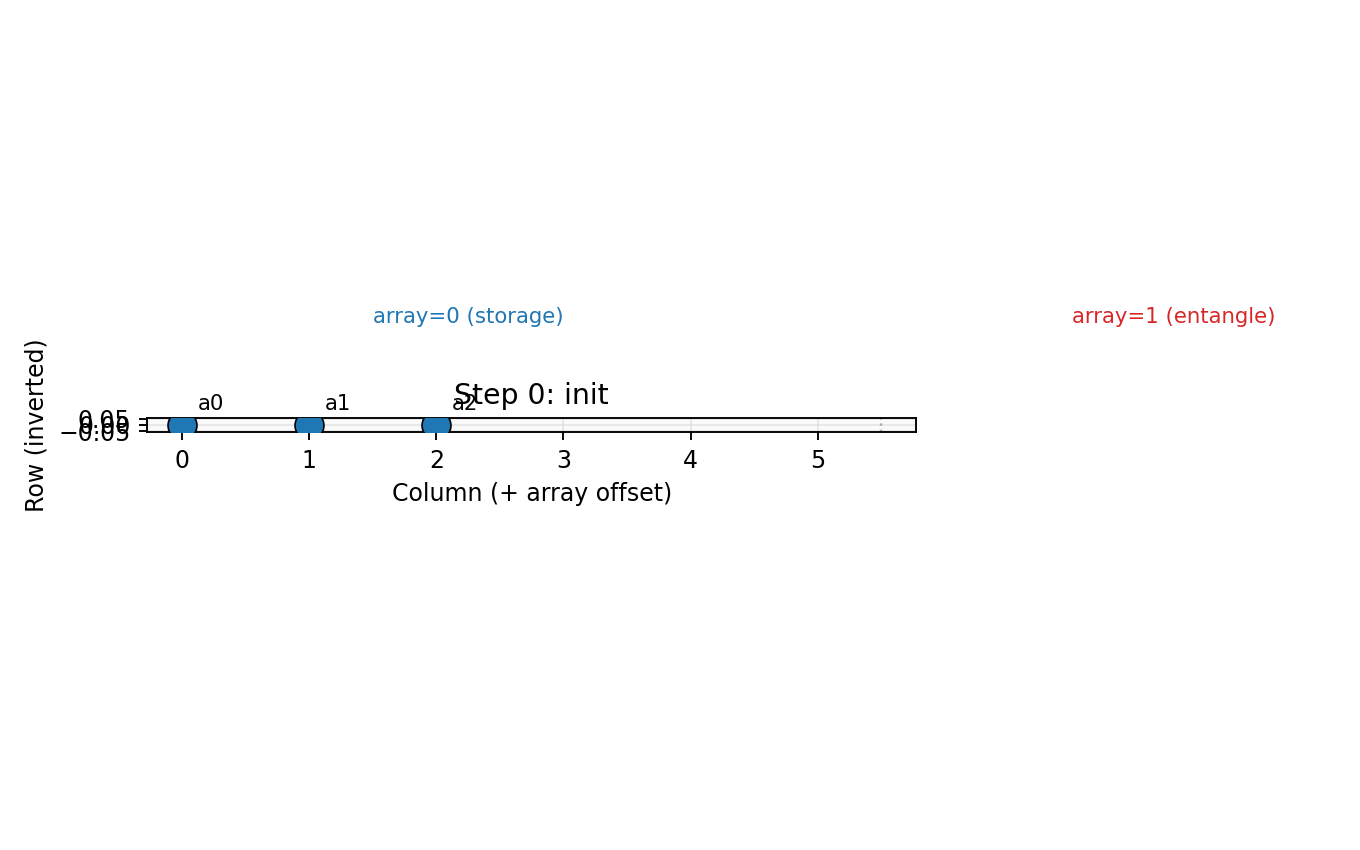

step_001.png


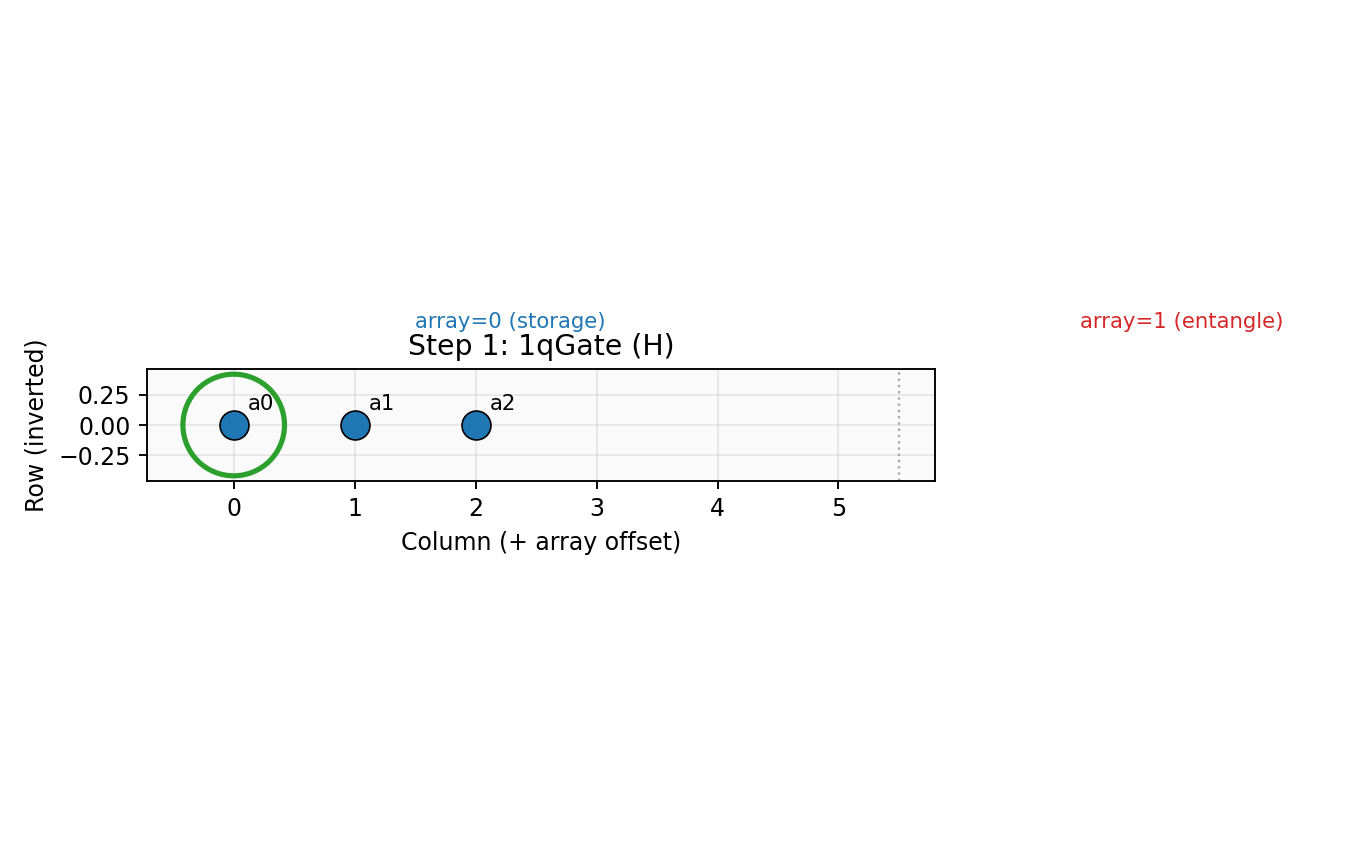

step_005.png


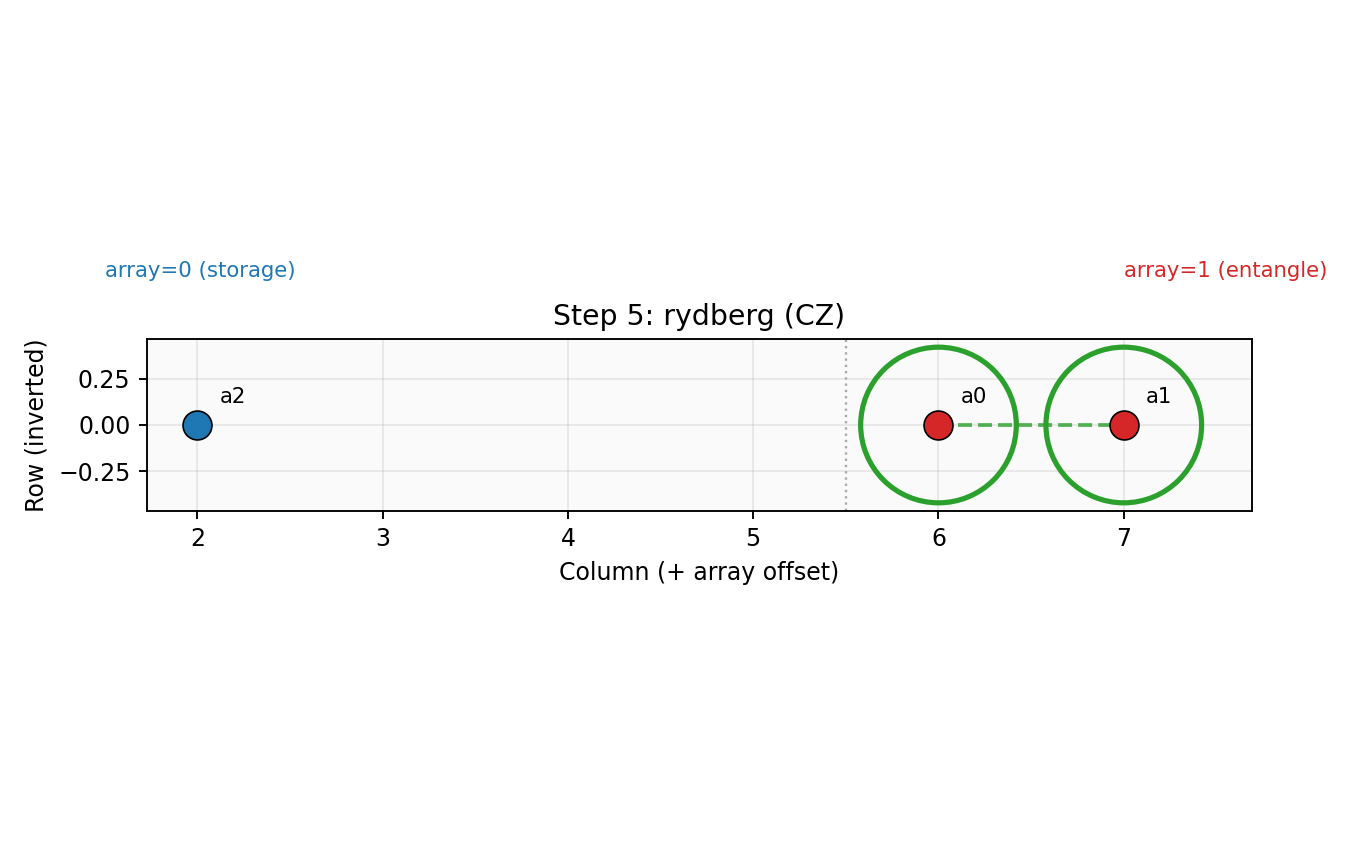

step_010.png


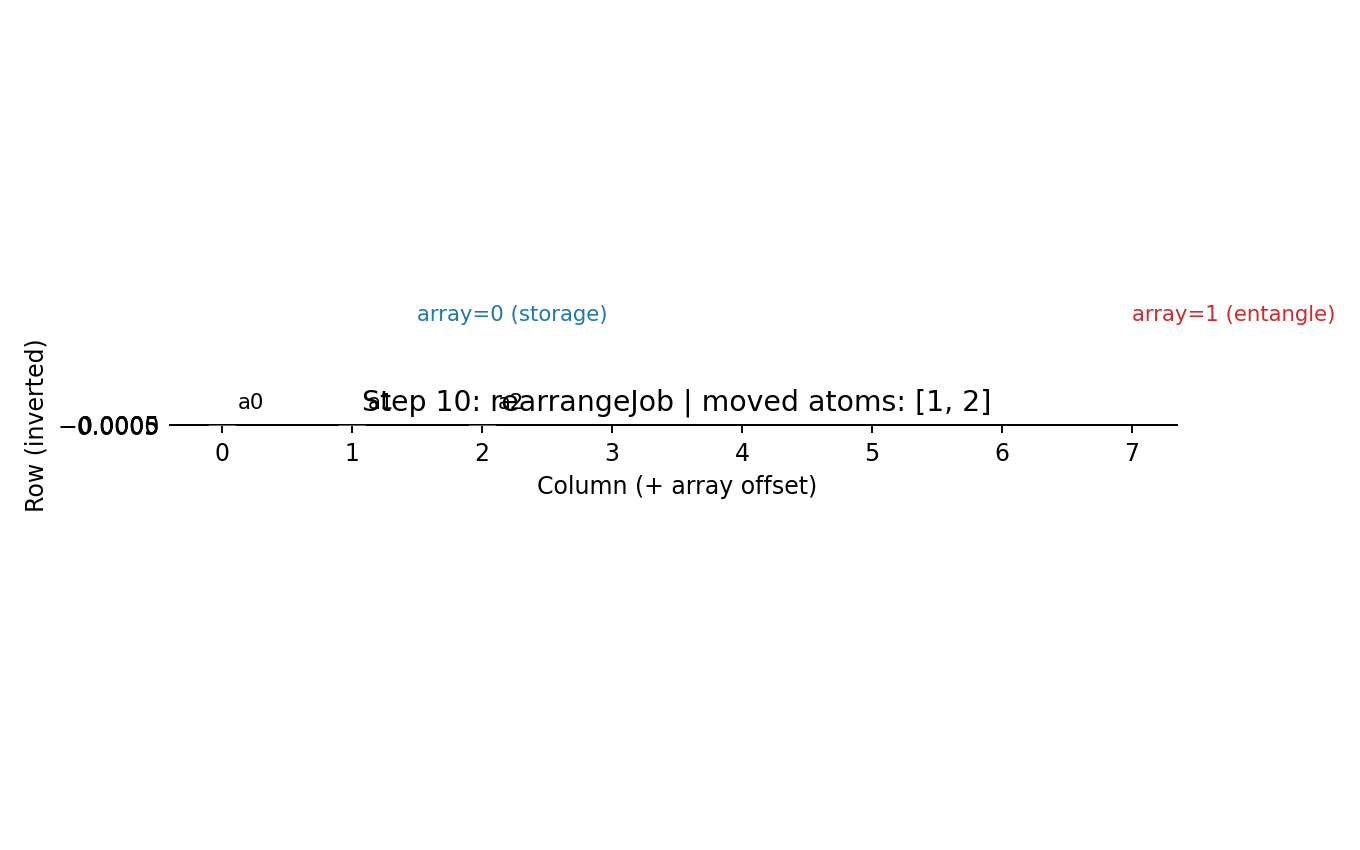

In [15]:
# Display several key spatial frames in notebook

from IPython.display import Image, display



preview_ids = [0, 1, max(1, len(schedule['instructions']) // 2), len(schedule['instructions']) - 1]

preview_ids = sorted(set(i for i in preview_ids if i >= 0))



for i in preview_ids:

    frame = Path('viz_outputs/spatial_frames') / f'step_{i:03d}.png'

    if frame.exists():

        print(frame.name)

        display(Image(filename=str(frame)))